# Chapter 19: When Another Mind Becomes Part of the World

Two controllers coordinate well with copies of themselves and badly with each other. Their private conventions are useful locally but do not travel. A deployment that changes partners can therefore change the effective environment without changing either controller's underlying model.

This notebook makes the distinction visible in a cross-play matrix. Rows are candidate policies and columns are partners. Diagonal cells measure matching-policy coordination, while off-diagonal cells reveal transfer. Weighted row values answer a deployment question: which policy works best against the partners expected here? A changed supervisor distribution can reverse the preferred policy, so diagonal success alone is an incomplete selection rule.

**Outcome:** Compute diagonal, cross-play, and deployment-mixture performance.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For matrix M_ij, mean self-play is the average diagonal value. Mean cross-play averages off-diagonal values when at least two policies exist. These descriptive summaries weight their cells uniformly; they are not automatically the deployment estimand.

With target partner weights w_j summing to one, policy i has value V_i=sum_j w_j M_ij. A second weight vector computes another environment mixture over the same columns. Selecting argmax_i V_i conditions the recommendation on that distribution. Changing weights can reverse the winner even when every matrix entry is fixed.

The supplied entries are probabilities or compatible normalized performance values under a shared success definition. The runtime does not estimate them from counts. Matching task distributions, budgets, and measurement rules is an assumption of the comparison. If partners adapt to the selected policy, a frozen matrix may cease to describe their behavior; the report should then become a dynamic-game measurement design rather than a static guarantee.

## A calculation you can run

Provide a square matrix and two normalized column-weight vectors. The function validates probabilities and dimensions, computes diagonal and off-diagonal summaries, then evaluates every row under both mixtures. It returns selected policy indices and their expected mixture values.

The figures show self-play diagonal values, partner-transfer values, and changed-supervisor values separately. Policy index identifies each row; retain a name mapping in reader notes when policies have operational names. In the changed case the primary partner mixture becomes concentrated on column 0. Predict whether that favors the first policy's strong diagonal or the second policy's more even transfer. No matrix observations change.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 19
inputs = {'matrix': [[0.95, 0.2], [0.4, 0.9]],
 'partner_weights': [0.5, 0.5],
 'supervisor_weights': [0.9, 0.1]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 19: cross-play-transfer
Does successful self-play transfer to the partners the controller will actually meet?
Evidence: constructed teaching example

Calculated quantities:
{
  "mean_self_play": 0.925,
  "mean_cross_play": 0.3,
  "joint_policy_correlation_loss": 0.6756756757,
  "partner_mixture_values": [
    0.575,
    0.65
  ],
  "supervisor_mixture_values": [
    0.875,
    0.45
  ],
  "selected_policy": 1,
  "supervisor_selected_policy": 0
}

Interpretation:
joint_policy_correlation_loss is Equation 19.2: (mean diagonal minus mean off-diagonal) divided by mean diagonal, computed here from the supplied matrix. Diagonal success measures coordination with matching partners. Off-diagonal entries and target weights determine transfer to other partners.

Assumptions:
- Matrix cells use matched tasks, budgets, and success definitions.
- Partner and supervisor weights are declared deployment mixtures.

Limitations:
- Changing counterparties can change the environment itself.
- A su

Default mean self-play is (0.95+0.9)/2=0.925. Mean cross-play is (0.2+0.4)/2=0.3, so the proportional loss of Equation 19.2 is (0.925-0.3)/0.925, about 0.676, which the report returns as joint_policy_correlation_loss. Under equal partner weights, policy 0 scores 0.575 and policy 1 scores 0.65, so policy 1 wins despite policy 0's stronger diagonal.

With weights [0.9,0.1], policy 0 scores 0.875 and policy 1 scores 0.45. The preferred policy reverses. The second supervisor mixture already demonstrates that reversal in the default report. Interpret it as conditional transfer across partner distributions, not proof that one policy is intrinsically more cooperative.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


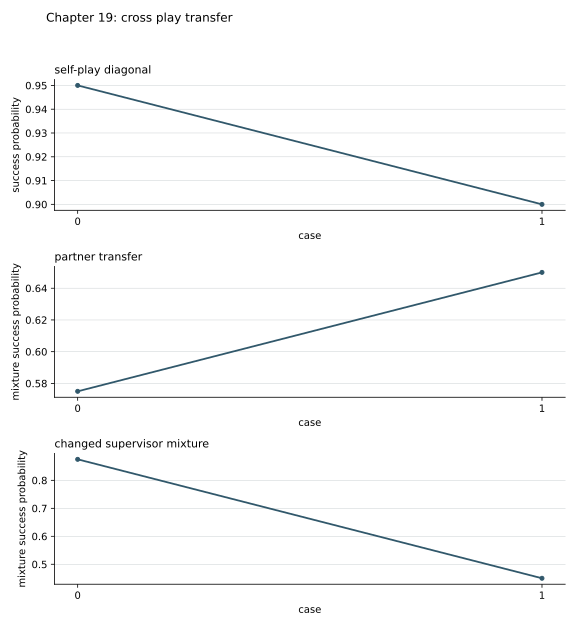

In [3]:
display(SVG(figure_svg(report)))

**Figure 19.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A cross-play matrix can conceal unmatched conditions. If one row receives easier tasks, more time, or a different supervisor, weighted averages compare more than policy behavior. Preserve those conditions before treating a cell difference as transfer evidence.

Uniform off-diagonal averaging is also easy to misuse. The deployed system may almost never encounter some partners, while frequently meeting an omitted partner. A high average across the supplied bank says little about an unsupported population.

Another failure is strategic adaptation. A partner that reacts to the deployed policy creates a changing environment. Static matrix values may describe the initial interaction but not later equilibria. This laboratory calculates a declared finite comparison and does not infer common knowledge, incentives, or an equilibrium from success entries.

Chapter 19: cross-play-transfer
Does successful self-play transfer to the partners the controller will actually meet?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "mean_self_play": 0.925,
  "mean_cross_play": 0.3,
  "joint_policy_correlation_loss": 0.6756756757,
  "partner_mixture_values": [
    0.875,
    0.45
  ],
  "supervisor_mixture_values": [
    0.875,
    0.45
  ],
  "selected_policy": 0,
  "supervisor_selected_policy": 0
}

Interpretation:
joint_policy_correlation_loss is Equation 19.2: (mean diagonal minus mean off-diagonal) divided by mean diagonal, computed here from the supplied matrix. Diagonal success measures coordination with matching partners. Off-diagonal entries and target weights determine transfer to other partners.

Assumptions:
- Matrix cells use matched tasks, budgets, and success definitions.
- Partner and supervisor weights are declared deployment mixtures.

Limitations:
- Changing counterparties can change the environment itse

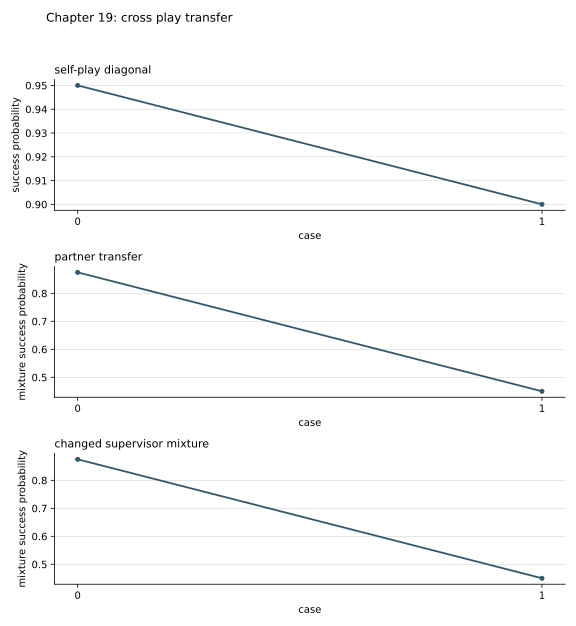

In [4]:
changed_inputs = {'matrix': [[0.95, 0.2], [0.4, 0.9]],
 'partner_weights': [0.9, 0.1],
 'supervisor_weights': [0.9, 0.1]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 19.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer matrix includes a specialist for column 0, a generalist with success 0.6 everywhere, and a specialist for column 2. Under weights [0.2,0.6,0.2], the generalist wins at 0.6 while each specialist scores 0.2. Concentrating the supervisor on the two extreme columns gives the specialists 0.5 each, still below 0.6.

For local data, collect off-diagonal cells deliberately rather than testing only familiar pairings. Record counts and uncertainty separately if entries are estimates. Define the partner mixture relevant to deployment and inspect plausible shifts before choosing a policy. Self-play remains a useful diagnostic, but it answers a narrower question.

In [5]:
transfer_inputs = {'matrix': [[1, 0, 0], [0.6, 0.6, 0.6], [0, 0, 1]],
 'partner_weights': [0.2, 0.6, 0.2],
 'supervisor_weights': [0.5, 0, 0.5]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 19: cross-play-transfer
Does successful self-play transfer to the partners the controller will actually meet?
Evidence: constructed transfer example

Calculated quantities:
{
  "mean_self_play": 0.8666666667,
  "mean_cross_play": 0.2,
  "joint_policy_correlation_loss": 0.7692307692,
  "partner_mixture_values": [
    0.2,
    0.6,
    0.2
  ],
  "supervisor_mixture_values": [
    0.5,
    0.6,
    0.5
  ],
  "selected_policy": 1,
  "supervisor_selected_policy": 1
}

Interpretation:
joint_policy_correlation_loss is Equation 19.2: (mean diagonal minus mean off-diagonal) divided by mean diagonal, computed here from the supplied matrix. Diagonal success measures coordination with matching partners. Off-diagonal entries and target weights determine transfer to other partners.

Assumptions:
- Matrix cells use matched tasks, budgets, and success definitions.
- Partner and supervisor weights are declared deployment mixtures.

Limitations:
- Changing counterparties can change the environ

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **matrix:** Square policy by partner success-probability matrix, entries in [0,1].
- **partner_weights:** Normalized target partner distribution.
- **supervisor_weights:** Normalized changed partner or supervisor distribution over the same columns.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch19.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 19: cross-play-transfer
Does successful self-play transfer to the partners the controller will actually meet?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "mean_self_play": 0.8666666667,
  "mean_cross_play": 0.2,
  "joint_policy_correlation_loss": 0.7692307692,
  "partner_mixture_values": [
    0.2,
    0.6,
    0.2
  ],
  "supervisor_mixture_values": [
    0.5,
    0.6,
    0.5
  ],
  "selected_policy": 1,
  "supervisor_selected_policy": 1
}

Interpretation:
joint_policy_correlation_loss is Equation 19.2: (mean diagonal minus mean off-diagonal) divided by mean diagonal, computed here from the supplied matrix. Diagonal success measures coordination with matching partners. Off-diagonal entries and target weights determine transfer to other partners.

Assumptions:
- Matrix cells use matched tasks, budgets, and success definitions.
- Partner and supervisor weights are declared deployment mixtures.

Limitations:
- Changing count

## Questions

1. Compute default policy 1 mixture value.

2. Why does the changed mixture favor policy 0?

3. Which transfer policy wins?

Answers: [separate solutions](../solutions/ch19.md). Try the calculation before opening them.

## Summary

Self-play measures coordination with a matching partner; cross-play tests transfer. Deployment choice depends on partner weights, and changed counterparties can reverse rankings without changing policies. The notebook separates these quantities and checks a specialist/generalist transfer case. Its matrix is a finite declared environment, not a universal cooperation score or dynamic equilibrium model. Preserve matched conditions and the intended partner population beside the result.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-19-cross-play-transfer`](../skills/maa-19-cross-play-transfer/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 19.1

![Equation 19.1](../assets/math/e5e2d644660293fd85ea.svg)

Equation (19.1) records what happens when a policy from one training run meets a policy from another.

Take party one's policy from run `s`, party two's from run `t`, play them together, and average the return.

LaTeX source, preserved for inspection:

```latex
M_{st} \;=\; \mathrm{E}\Big[\,u\big(\pi_1^{(s)},\,\pi_2^{(t)}\big)\Big].
\tag{19.1}
```

### Equation 19.2

![Equation 19.2](../assets/math/b8cfa44bbf5609ac31b6.svg)

Equation (19.2) normalizes the measured matched-partner gap under the declared procedure.

Subtract the average score against strangers from the average score against training partners, and divide by the latter.

LaTeX source, preserved for inspection:

```latex
\operatorname{JPC}(M) \;=\; \frac{\operatorname{diag}(M) - \operatorname{off}(M)}{\operatorname{diag}(M)}.
\tag{19.2}
```

### Equation 19.3

![Equation 19.3](../assets/math/620a3d1e80b330eeb468.svg)

Equation (19.3) exposes a policy dependence that must be checked before applying a stationary-system guarantee.

The distribution over next states now depends on the other party's policy as well as on the state and the action.

LaTeX source, preserved for inspection:

```latex
P\big(x' \mid x, a\big) \;\longrightarrow\; P\big(x' \mid x, a,\, \pi_{-i}\big).
\tag{19.3}
```

### Equation 19.4

![Equation 19.4](../assets/math/778d192b670fc1a2a421.svg)

Equation (19.4) gives the best an agent can do against a stated opponent policy.

Choose the policy maximizing this party's payoff, holding the other party's policy fixed.

LaTeX source, preserved for inspection:

```latex
\operatorname{BR}_i(\pi_{-i}) \;=\; \arg\max_{\pi_i}\; u_i\big(\pi_i, \pi_{-i}\big).
\tag{19.4}
```